In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_men =pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")


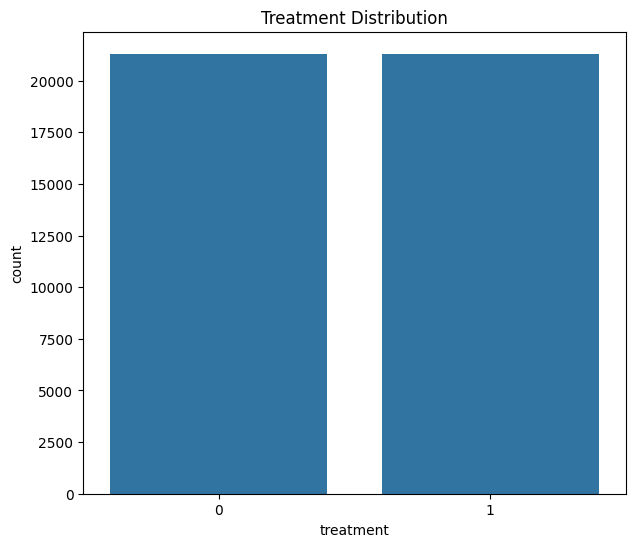

In [3]:
plt.figure(figsize=(7,6))
sns.countplot(data = df_men, x = 'treatment')
plt.title("Treatment Distribution")
plt.show()

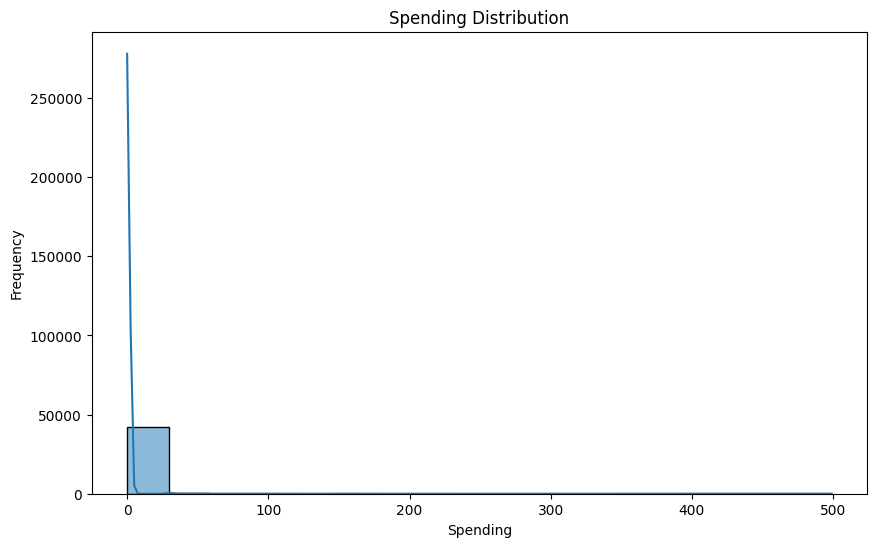

In [4]:
plt.figure(figsize=(10,6))
sns.histplot(data= df_men, x="spend", kde=True)
plt.title('Spending Distribution')
plt.xlabel('Spending')
plt.ylabel('Frequency')
plt.show()

spend
0.00      42224
29.99        96
30.24         1
30.94         1
30.98         1
          ...  
421.76        1
444.33        1
444.92        1
482.31        1
499.00        8
Name: count, Length: 288, dtype: int64
Percentage of customers who didn't spend: 99.08713303451998%


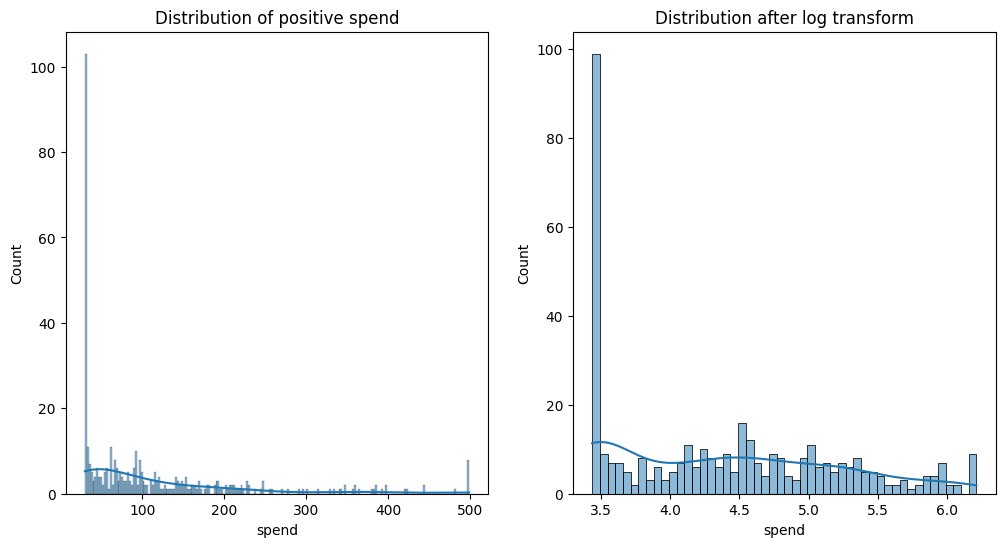

In [5]:
#EDA Spend
spend_count = df_men["spend"].value_counts()
print(spend_count.sort_index())

zero_fraction  = (df_men["spend"]==0).mean()
print (f"Percentage of customers who didn't spend: {zero_fraction*100}%")

positive_spend = df_men[df_men["spend"]>0]["spend"]

fig, axes = plt.subplots(1,2, figsize=(12,6))

sns.histplot(data= positive_spend, bins = 200, ax=axes[0], kde = True)
axes[0].set_title("Distribution of positive spend")

sns.histplot(data= np.log1p(positive_spend), bins = 50, ax=axes[1], kde=True)
axes[1].set_title("Distribution after log transform")
plt.show()

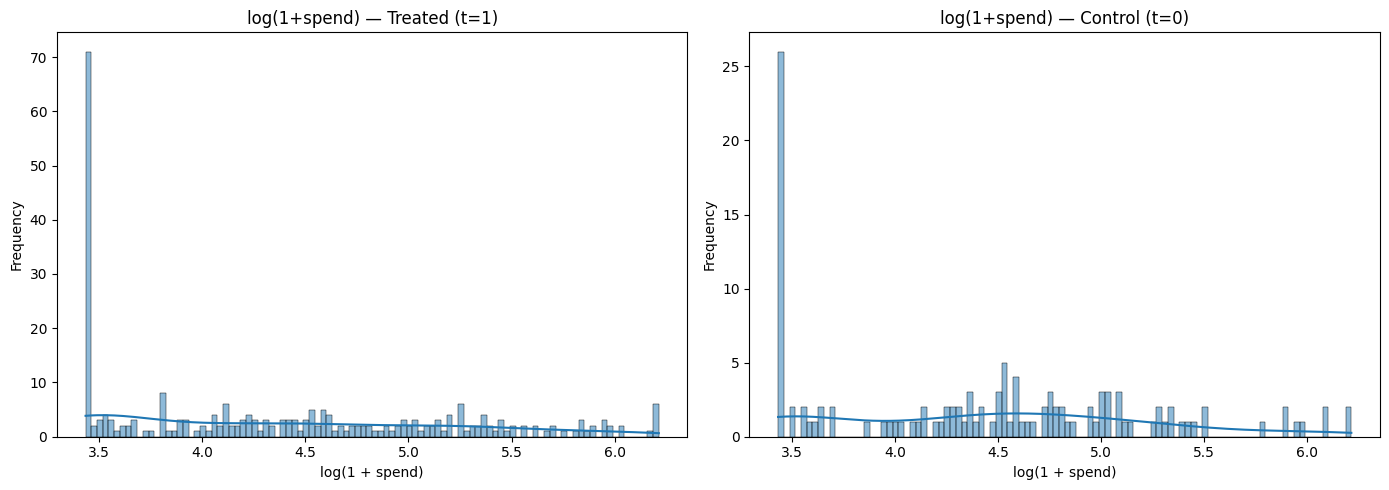

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group, label in zip(axes, [1, 0], ["Treated (t=1)", "Control (t=0)"]):
    pos = df_men.loc[(df_men["treatment"] == group) & (df_men["spend"] > 0), "spend"]
    sns.histplot(np.log1p(pos), bins=100, kde=True, ax=ax)
    ax.set_title(f"log(1+spend) — {label}")
    ax.set_xlabel("log(1 + spend)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

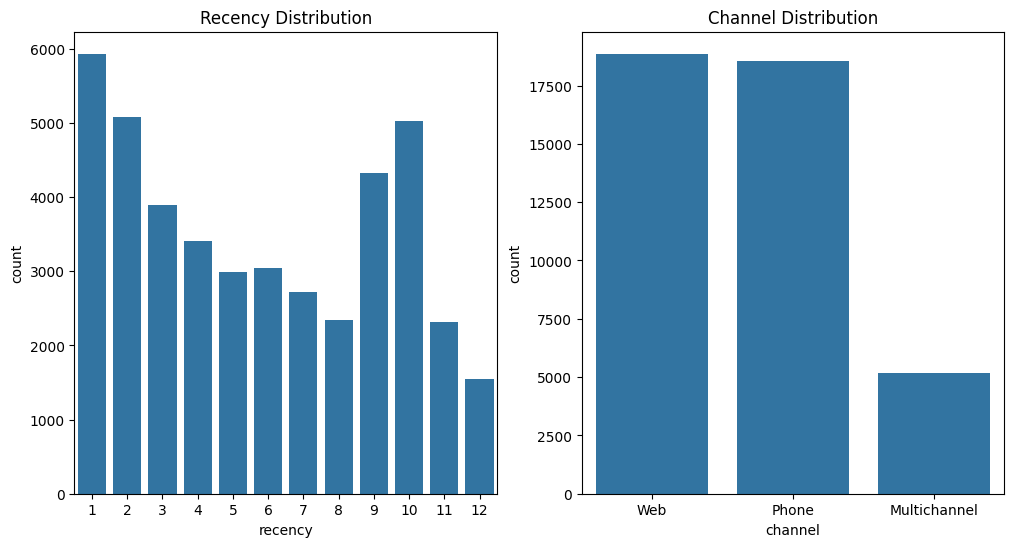

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,6))
sns.countplot(data = df_men, x = 'recency', ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.countplot(data = df_men, x = "channel", ax=axes[1])
axes[1].set_title("Channel Distribution")

plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# ATE & KEY STATISTICS — Hillstrom Men
# ═══════════════════════════════════════════════════════════════════════════

t = df_men["treatment"].values
y = df_men["spend"].values

# ── 1. ATE (Average Treatment Effect) ────────────────────────────────────
ate_spend = y[t == 1].mean() - y[t == 0].mean()
print("=" * 60)
print("ATE (Average Treatment Effect)")
print("=" * 60)
print(f"  Avg spend (treated):  {y[t==1].mean():.4f}")
print(f"  Avg spend (control):  {y[t==0].mean():.4f}")
print(f"  ATE (spend):          {ate_spend:.4f}")
print(f"  ATE > 0 → email campaign {'INCREASES' if ate_spend > 0 else 'DECREASES'} spending")

# ── 2. Conversion-based ATE ──────────────────────────────────────────────
conv = df_men["conversion"].values
ate_conv = conv[t == 1].mean() - conv[t == 0].mean()
print(f"\n  Conversion rate (treated): {conv[t==1].mean():.4%}")
print(f"  Conversion rate (control): {conv[t==0].mean():.4%}")
print(f"  ATE (conversion):          {ate_conv:.4%}")

# ── 3. Visit-based ATE ───────────────────────────────────────────────────
visit = df_men["visit"].values
ate_visit = visit[t == 1].mean() - visit[t == 0].mean()
print(f"\n  Visit rate (treated): {visit[t==1].mean():.4%}")
print(f"  Visit rate (control): {visit[t==0].mean():.4%}")
print(f"  ATE (visit):          {ate_visit:.4%}")

# ── 4. Dataset overview ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print(f"{'='*60}")
print(f"  Total samples:      {len(df_men)}")
print(f"  Treated:            {(t==1).sum()} ({(t==1).mean():.1%})")
print(f"  Control:            {(t==0).sum()} ({(t==0).mean():.1%})")
print(f"  Zero spend:         {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  Positive spend:     {(y>0).sum()} ({(y>0).mean():.1%})")

# ── 5. Spend distribution by group ───────────────────────────────────────
print(f"\n{'='*60}")
print("SPEND BY GROUP")
print(f"{'='*60}")
for group, label in [(1, "Treated"), (0, "Control")]:
    yg = y[t == group]
    pos = yg[yg > 0]
    print(f"\n  {label}:")
    print(f"    Mean spend (all):      {yg.mean():.4f}")
    print(f"    Median spend (all):    {np.median(yg):.4f}")
    print(f"    Std spend (all):       {yg.std():.4f}")
    print(f"    Positive rate:         {(yg>0).mean():.4%}")
    if len(pos) > 0:
        print(f"    Mean spend (if > 0):   {pos.mean():.4f}")
        print(f"    Median spend (if > 0): {np.median(pos):.4f}")
    print(f"    Max spend:             {yg.max():.4f}")

# ── 6. Statistical significance ──────────────────────────────────────────
from scipy.stats import ttest_ind, mannwhitneyu
print(f"\n{'='*60}")
print("STATISTICAL SIGNIFICANCE")
print(f"{'='*60}")
t_stat, p_val = ttest_ind(y[t==1], y[t==0])
print(f"  t-test (spend):      t={t_stat:.4f}, p={p_val:.4f} {'✅ Sig' if p_val < 0.05 else '❌ Not sig'}")

u_stat, p_val_u = mannwhitneyu(y[t==1], y[t==0], alternative='two-sided')
print(f"  Mann-Whitney (spend): U={u_stat:.0f}, p={p_val_u:.4f} {'✅ Sig' if p_val_u < 0.05 else '❌ Not sig'}")

t_stat_c, p_val_c = ttest_ind(conv[t==1], conv[t==0])
print(f"  t-test (conversion): t={t_stat_c:.4f}, p={p_val_c:.4f} {'✅ Sig' if p_val_c < 0.05 else '❌ Not sig'}")

ATE (Average Treatment Effect)
  Avg spend (treated):  1.4226
  Avg spend (control):  0.6528
  ATE (spend):          0.7698
  ATE > 0 → email campaign INCREASES spending

  Conversion rate (treated): 1.2531%
  Conversion rate (control): 0.5726%
  ATE (conversion):          0.6805%

  Visit rate (treated): 18.2757%
  Visit rate (control): 10.6167%
  ATE (visit):          7.6590%

DATASET OVERVIEW
  Total samples:      42613
  Treated:            21307 (50.0%)
  Control:            21306 (50.0%)
  Zero spend:         42224 (99.1%)
  Positive spend:     389 (0.9%)

SPEND BY GROUP

  Treated:
    Mean spend (all):      1.4226
    Median spend (all):    0.0000
    Std spend (all):       17.7538
    Positive rate:         1.2531%
    Mean spend (if > 0):   113.5269
    Median spend (if > 0): 66.9800
    Max spend:             499.0000

  Control:
    Mean spend (all):      0.6528
    Median spend (all):    0.0000
    Std spend (all):       11.5879
    Positive rate:         0.5726%
    Mean 